# Copy-Paste Data Augmentation for Drill Bit Defects

This notebook focuses on augmenting all defect classes while maintaining the original data distribution:
- **Broken** (Class 0)
- **Chipped** (Class 1)
- **Scratched** (Class 2)
- **Severe_Rust** (Class 3)
- **Tip_Wear** (Class 4)

The copy-paste augmentation crops defect instances from the training set and pastes them at random valid positions on other training images, matching the class of the reference defect on the target image. This preserves the relative frequency (distribution) of all defect classes.


In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random
import glob

# Set seed for reproducibility
random.seed(42)
np.random.seed(42)

dataset_path = "/Users/mac/Detect_Drill_Bit/final-dataset"
train_images_dir = os.path.join(dataset_path, "train/images")
train_labels_dir = os.path.join(dataset_path, "train/labels")
classes = ['Broken', 'Chipped', 'Scratched', 'Severe_Rust', 'Tip_Wear']
target_classes = [0, 1, 2, 3, 4] # Augment all classes


Defect counts before augmentation:
  Broken: 747 instances
  Chipped: 1134 instances
  Scratched: 1367 instances
  Severe_Rust: 1205 instances
  Tip_Wear: 907 instances


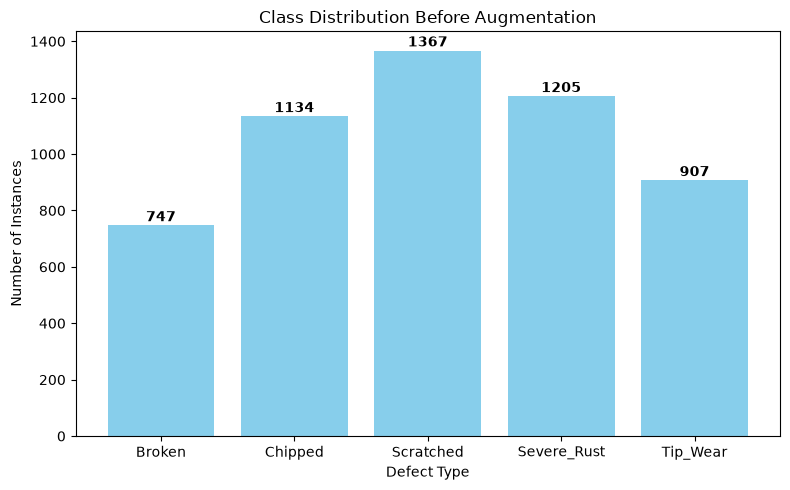

In [2]:
def get_class_distribution(labels_dir):
    counts = Counter()
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    for lf in label_files:
        # Ignore already augmented files to get clean baseline
        if os.path.basename(lf).startswith("aug_"):
            continue
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

counts_before = get_class_distribution(train_labels_dir)
print("Defect counts before augmentation:")
for idx, name in enumerate(classes):
    print(f"  {name}: {counts_before[idx]} instances")

# Plot distribution before
plt.figure(figsize=(8, 5))
plt.bar(classes, [counts_before[i] for i in range(5)], color='skyblue')
plt.title("Class Distribution Before Augmentation")
plt.xlabel("Defect Type")
plt.ylabel("Number of Instances")
for i, v in enumerate([counts_before[i] for i in range(5)]):
    plt.text(i, v + 15, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


In [3]:
def crop_rois(images_dir, labels_dir, target_classes):
    rois = {c: [] for c in target_classes}
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    
    for lf in label_files:
        if os.path.basename(lf).startswith("aug_"):
            continue
        
        img_name = os.path.basename(lf).replace(".txt", ".jpg")
        img_path = os.path.join(images_dir, img_name)
        if not os.path.exists(img_path):
            img_name = img_name.replace(".jpg", ".png")
            img_path = os.path.join(images_dir, img_name)
            if not os.path.exists(img_path):
                continue
                
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        h_img, w_img = img.shape[:2]
        
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                if cls_id in target_classes:
                    x_c, y_c, w, h = map(float, parts[1:])
                    # Denormalize
                    x1 = int((x_c - w/2) * w_img)
                    y1 = int((y_c - h/2) * h_img)
                    x2 = int((x_c + w/2) * w_img)
                    y2 = int((y_c + h/2) * h_img)
                    
                    x1 = max(0, x1)
                    y1 = max(0, y1)
                    x2 = min(w_img, x2)
                    y2 = min(h_img, y2)
                    
                    if (x2 - x1) > 2 and (y2 - y1) > 2:
                        roi = img[y1:y2, x1:x2].copy()
                        rois[cls_id].append({
                            'roi': roi,
                            'w_rel': w,
                            'h_rel': h
                        })
    return rois

rois = crop_rois(train_images_dir, train_labels_dir, target_classes)
for c in target_classes:
    print(f"Extracted {len(rois[c])} ROIs for class '{classes[c]}'")


Extracted 747 ROIs for class 'Broken'
Extracted 1134 ROIs for class 'Chipped'
Extracted 1367 ROIs for class 'Scratched'
Extracted 1205 ROIs for class 'Severe_Rust'
Extracted 907 ROIs for class 'Tip_Wear'


In [4]:
def apply_copy_paste(img, existing_labels, rois, num_pastes=2):
    h_img, w_img = img.shape[:2]
    new_labels = list(existing_labels)
    aug_img = img.copy()
    
    if not existing_labels:
        return None, None
        
    # Create foreground mask of the drill bit
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, fg_mask = cv2.threshold(gray_img, 30, 255, cv2.THRESH_BINARY)
    
    # Shuffle references to avoid pasting on the same anchor twice in the same image
    ref_labels = list(existing_labels)
    random.shuffle(ref_labels)
    
    pastes_done = 0
    for ref_label in ref_labels:
        if pastes_done >= num_pastes:
            break
            
        ref_cls, ref_xc, ref_yc, ref_w, ref_h = ref_label
        cls_id = ref_cls
        if not rois[cls_id]:
            continue
        roi_info = random.choice(rois[cls_id])
        roi = roi_info['roi'].copy()
        
        # Random flipping
        if random.random() > 0.5:
            roi = cv2.flip(roi, 1)
        if random.random() > 0.5:
            roi = cv2.flip(roi, 0)
            
        # Scale proportional to reference defect size
        scale = random.uniform(0.85, 1.1)
        new_w = int(ref_w * w_img * scale)
        new_h = int(ref_h * h_img * scale)
        
        new_w = np.clip(new_w, 6, int(w_img * 0.25))
        new_h = np.clip(new_h, 6, int(h_img * 0.25))
        roi = cv2.resize(roi, (new_w, new_h))
        
        # Shift vertically to place near the anchor but without direct overlap
        valid = False
        x_c, y_c = 0, 0
        
        # Try shifting below first, then above
        for direction in [1, -1]:
            # Shift vertically by at least 1.1x height to prevent overlap
            dy_rel = direction * (ref_h * random.uniform(1.1, 1.6))
            dx_rel = random.uniform(-ref_w * 0.2, ref_w * 0.2)
            
            x_c_rel = ref_xc + dx_rel
            y_c_rel = ref_yc + dy_rel
            
            x_c = int(x_c_rel * w_img)
            y_c = int(y_c_rel * h_img)
            
            x1 = x_c - new_w // 2
            y1 = y_c - new_h // 2
            x2 = x1 + new_w
            y2 = y1 + h_img
            
            x2 = x_c + new_w // 2
            y2 = y_c + new_h // 2
            
            if x1 >= 0 and y1 >= 0 and x2 <= w_img and y2 <= h_img:
                # Check overlap with ALL labels currently on this image
                overlap = False
                for lbl in new_labels:
                    l_cls, l_xc, l_yc, l_w, l_h = lbl
                    lx1 = int((l_xc - l_w/2) * w_img)
                    ly1 = int((l_yc - l_h/2) * h_img)
                    lx2 = int((l_xc + l_w/2) * w_img)
                    ly2 = int((l_yc + l_h/2) * h_img)
                    
                    # Compute intersection area
                    ix1 = max(x1, lx1)
                    iy1 = max(y1, ly1)
                    ix2 = min(x2, lx2)
                    iy2 = min(y2, ly2)
                    
                    if ix1 < ix2 and iy1 < iy2:
                        intersection_area = (ix2 - ix1) * (iy2 - iy1)
                        box_area = new_w * new_h
                        if intersection_area / box_area > 0.1:
                            overlap = True
                            break
                            
                if overlap:
                    continue
                    
                # Verify the shifted location is on the drill bit foreground
                fg_ratio = np.mean(fg_mask[y1:y2, x1:x2]) / 255.0
                if fg_ratio > 0.85:
                    valid = True
                    break
                    
        if not valid:
            continue
            
        # Seamless clone
        mask = np.ones(roi.shape[:2], dtype=np.uint8) * 255
        try:
            aug_img = cv2.seamlessClone(roi, aug_img, mask, (int(x_c), int(y_c)), cv2.MIXED_CLONE)
            new_labels.append([cls_id, x_c/w_img, y_c/h_img, new_w/w_img, new_h/h_img])
            pastes_done += 1
        except Exception as e:
            continue
        
    return aug_img, new_labels


In [5]:
# Delete existing augmented files first
for f in glob.glob(os.path.join(train_images_dir, "aug_cp_*")):
    os.remove(f)
for f in glob.glob(os.path.join(train_labels_dir, "aug_cp_*")):
    os.remove(f)
print("Deleted old augmented files.")

# Identify and select target images to augment (must contain existing labels)
original_images = [f for f in os.listdir(train_images_dir) if f.endswith(('.jpg', '.png')) and not f.startswith("aug_")]
valid_original_images = []

for img_name in original_images:
    label_name = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_name)
    if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
        valid_original_images.append(img_name)

print(f"Found {len(valid_original_images)} valid original training images with existing labels.")

num_to_augment = 1000
selected_images = random.sample(valid_original_images, min(num_to_augment, len(valid_original_images)))

augmented_count = 0
for img_name in selected_images:
    img_path = os.path.join(train_images_dir, img_name)
    label_name = os.path.splitext(img_name)[0] + ".txt"
    label_path = os.path.join(train_labels_dir, label_name)
    
    img = cv2.imread(img_path)
    if img is None:
        continue
        
    existing_labels = []
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                existing_labels.append([int(parts[0])] + [float(x) for x in parts[1:]])
                
    num_pastes = random.randint(1, 3)
    aug_img, new_labels = apply_copy_paste(img, existing_labels, rois, num_pastes=num_pastes)
    
    if aug_img is None or new_labels is None:
        continue
        
    new_img_name = f"aug_cp_{img_name}"
    new_label_name = f"aug_cp_{label_name}"
    
    cv2.imwrite(os.path.join(train_images_dir, new_img_name), aug_img)
    with open(os.path.join(train_labels_dir, new_label_name), 'w') as f:
        for lbl in new_labels:
            f.write(f"{lbl[0]} {' '.join(f'{x:.6f}' for x in lbl[1:])}\n")
            
    augmented_count += 1

print(f"Successfully generated and saved {augmented_count} augmented images and labels.")


Deleted old augmented files.


Found 3521 valid original training images with existing labels.


Successfully generated and saved 1000 augmented images and labels.


Defect counts after augmentation:
  Broken: 747 -> 1056 (+309)
  Chipped: 1134 -> 1545 (+411)
  Scratched: 1367 -> 1848 (+481)
  Severe_Rust: 1205 -> 1652 (+447)
  Tip_Wear: 907 -> 1213 (+306)


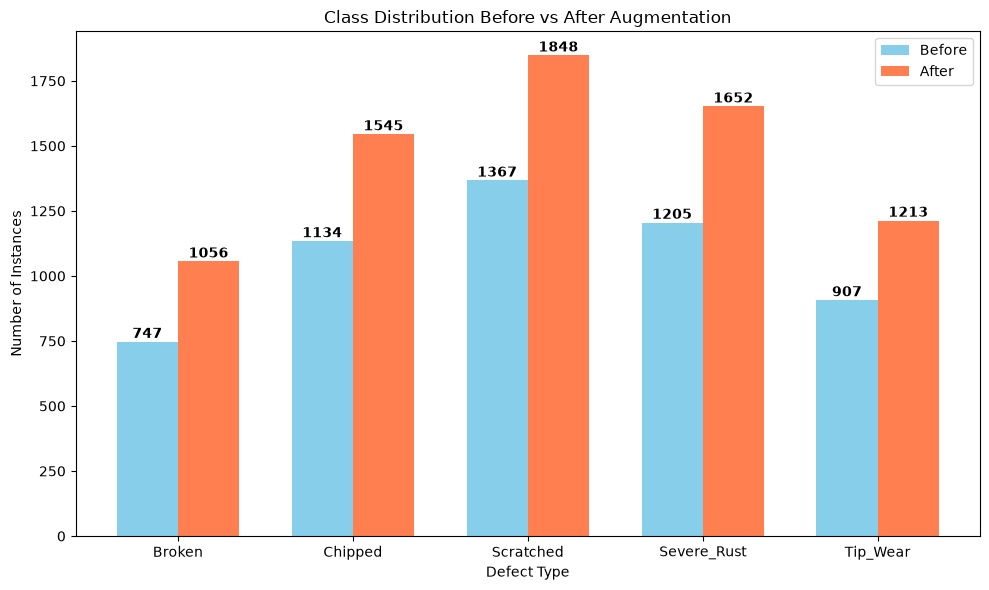

In [6]:
def get_all_class_distribution(labels_dir):
    counts = Counter()
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    for lf in label_files:
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    counts[int(parts[0])] += 1
    return counts

counts_after = get_all_class_distribution(train_labels_dir)
print("Defect counts after augmentation:")
for idx, name in enumerate(classes):
    diff = counts_after[idx] - counts_before[idx]
    print(f"  {name}: {counts_before[idx]} -> {counts_after[idx]} (+{diff})")

# Plot before vs after comparison
plt.figure(figsize=(10, 6))
x = np.arange(len(classes))
width = 0.35

plt.bar(x - width/2, [counts_before[i] for i in range(5)], width, label='Before', color='skyblue')
plt.bar(x + width/2, [counts_after[i] for i in range(5)], width, label='After', color='coral')

plt.title("Class Distribution Before vs After Augmentation")
plt.xlabel("Defect Type")
plt.ylabel("Number of Instances")
plt.xticks(x, classes)
plt.legend()

for i in range(5):
    plt.text(i - width/2, counts_before[i] + 15, str(counts_before[i]), ha='center', fontweight='bold')
    plt.text(i + width/2, counts_after[i] + 15, str(counts_after[i]), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


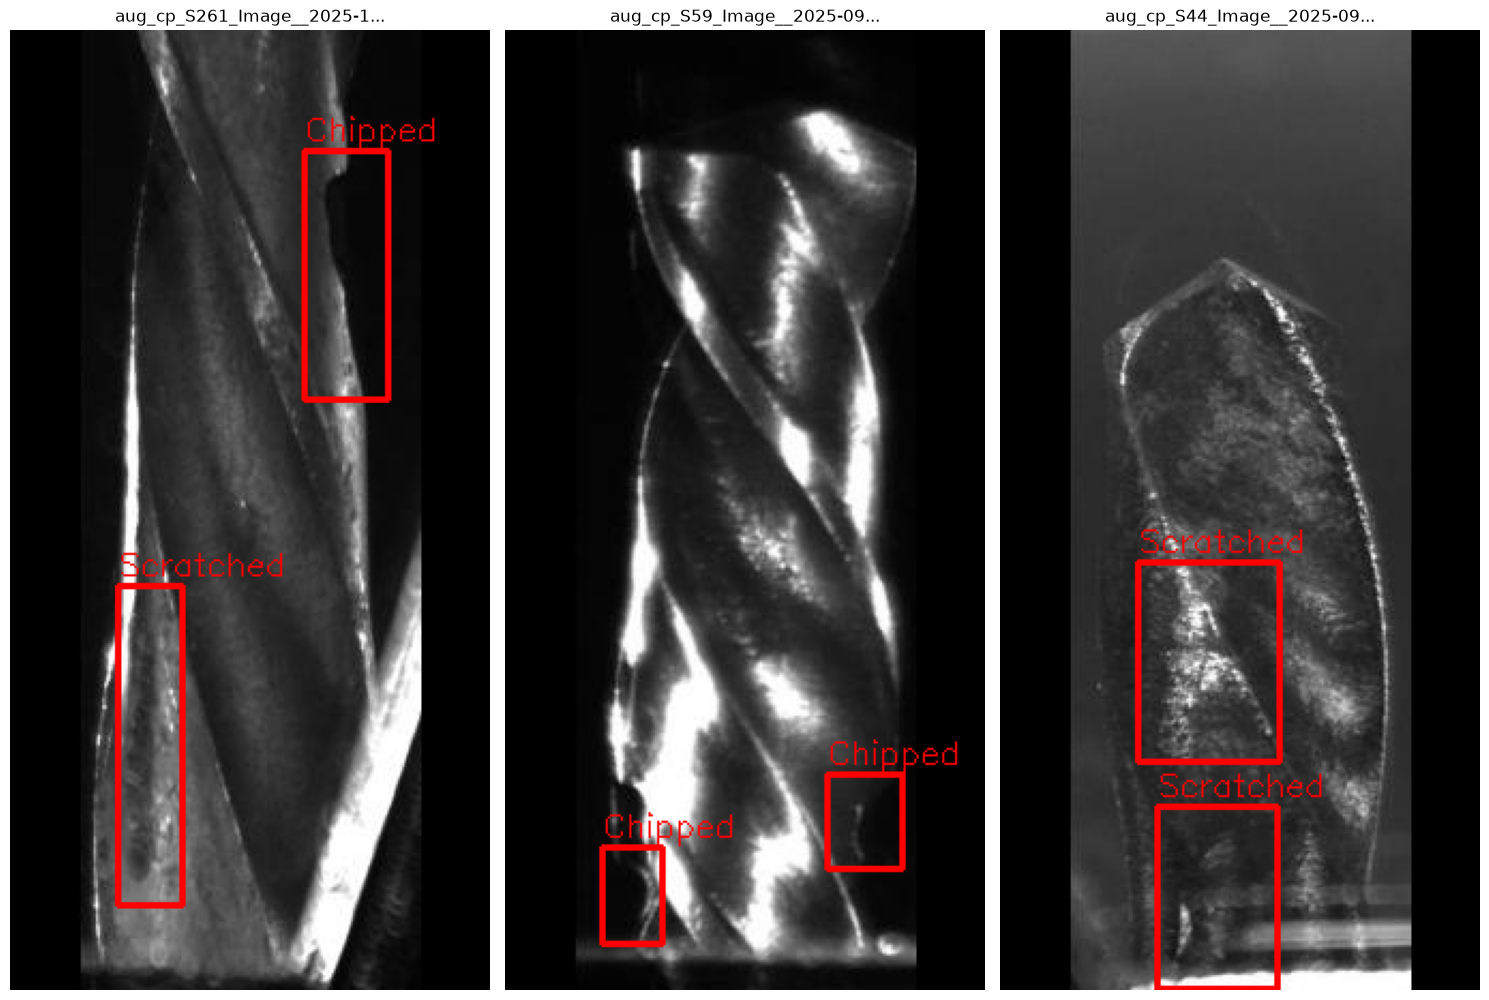

In [49]:
# Select 3 random augmented images and plot them with bounding boxes
aug_label_files = glob.glob(os.path.join(train_labels_dir, "aug_cp_*.txt"))
if aug_label_files:
    plt.figure(figsize=(15, 10))
    selected_aug_labels = random.sample(aug_label_files, min(3, len(aug_label_files)))
    
    for idx, lf in enumerate(selected_aug_labels):
        img_name = os.path.basename(lf).replace(".txt", ".jpg")
        img_path = os.path.join(train_images_dir, img_name)
        if not os.path.exists(img_path):
            img_path = img_path.replace(".jpg", ".png")
            
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h_img, w_img = img.shape[:2]
        
        with open(lf, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if not parts:
                    continue
                cls_id = int(parts[0])
                x_c, y_c, w, h = map(float, parts[1:])
                x1 = int((x_c - w/2) * w_img)
                y1 = int((y_c - h/2) * h_img)
                x2 = int((x_c + w/2) * w_img)
                y2 = int((y_c + h/2) * h_img)
                
                # Draw box
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
                
                # Safe Y coordinate for text (draw inside box if near the top edge)
                text_y = y1 - 5 if y1 - 5 > 15 else y1 + 15
                cv2.putText(img, classes[cls_id], (x1, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
                
        plt.subplot(1, 3, idx + 1)
        plt.imshow(img)
        plt.title(img_name[:25] + "...")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
